# Integral Losses approach 

We now control one normal SMD (no muscle example yet). 

Instead of comparing target and future state, we now compare the discounted summed (future) values of the target with the discounted
summed (future) values of the transformed state, from now to a time $t$ in the future. 

In [57]:
import sys
sys.path.append('/Users/paolo.agliati/Documents/Objective1/Linear Spiking Regulator/Code/obj1-spiking-lqr')
from scipy.linalg import expm
from scipy.integrate import quad_vec
import numpy as np
import matplotlib.pyplot as plt
import scipy.linalg as la
import control
import lib_sim
import lib_plot 
from importlib import reload
reload(lib_sim) 
reload(lib_plot)
import random 

In [58]:
N=2
M=1
K=2*M
np.random.seed(50)
random.seed(50)

#Time settings
T = 50
dt = 1e-2
time = np.arange(0, T, dt)
f = T
nT = len(time)
print("nT:", nT)

#State matrix and starting point
A = np.array([[0, 1],[-.1, -.1]])
x0 = ((0, 0))
x = np.zeros((N, nT))
x[:,0] = x0
A_f = la.expm(A*f)
#A_1= la.expm(A*dt)

#Spike mapping matrix 
B = np.zeros((2*M, N))
# Fill only even rows with random values
for i in range(1, 2 * M, 2):
    B[i] = np.random.randn(N)
# Normalize each column
B /= np.linalg.norm(B, axis=0)
for i in range(1, 2 * M, 2):
    B[i,1] = 2
    B[i,0] = -2
print("B:", B)

#Costs 
C = np.zeros((2, 2))
C[0, 0] = 1
C[1, 1] = 0

#Spikes, threshold scaling, voltage
s = np.zeros((K, nT))
Th = np.zeros((N, nT))
mu = 0.2
V = np.zeros((N, nT))
z = np.zeros((N, nT))


nT: 5000
B: [[ 0.  0.]
 [-2.  2.]]


In [59]:
#Target setup
z_base = np.zeros((N, nT)) # Define z_base as a step function
#z_base[0, 0:5000] = 50
z_base[0, 0:500] = 5
z_base[0, 500:1000] = -5
z_base[0, 1000:1500] = 10
z_base[0, 1500:2000] = -10
z_base[0, 2000:2500] = 15  
z_base[0, 2500:3500] = -15 
z_base[0, 3500:4000] = 20
z_base[0, 4000:5000] = -20

leak_z = 1

#Time settings and decay factor for discounted integral
can_spike = np.ones(N)
tau = int(f / (dt + 1e-8)) + 1
lam = 0.01

#Just for plotting non important variables
error_spiking = np.zeros((len(x[:, 0]), nT))
x_pred = np.zeros((N, nT)) #Predicted state


# --- Precompute M1 and M2 once before the loop ---
# n = A.shape[0]
def integrand_M1(t):
    At = expm(A * t)
    return At.T @ C * (lam ** (t))      # A_t^T C

def integrand_M2(t):
    At = expm(A * t)
    return At.T @ C @ At * (lam ** (t)) # A_t^T C A_t

M1, _ = quad_vec(integrand_M1, 0, f)
M2, _ = quad_vec(integrand_M2, 0, f)


# Threshold — mu added here as before
Th = np.diag(B.T @ M2 @ B + mu) / 2

# --- Simulation loop ---
for i in range(1, nT):
    # Update target
    z[0, i] = z[0, i-1] + dt * (leak_z * (z_base[0, i-1] - z[0, i-1]))

    # Update system state
    x[:, i] = x[:, i-1] + dt * (A @ x[:, i-1]) + B @ s[:, i-1]

    # Voltage update with discounted integral matrices
    V[:, i] = B.T @ (M1 @ z[:, i] - M2 @ x[:, i])    
       
    # Spike decision (unchanged)
    abovethreshold = np.where(V[:, i] > Th)[0]
    if len(abovethreshold) > 0:
        maxid = np.argmax(V[abovethreshold, i])
        tospike = abovethreshold[maxid]
        s[tospike, i] = 1
    
    x_pred[:, i] = A_f @ x[:, i]
    error_spiking[:, i] = (x[:, i] - z[0, i])

In [60]:
M1

array([[0.21614969, 0.        ],
       [0.04593876, 0.        ]])

In [61]:
M2

array([[0.21517853, 0.04533136],
       [0.04533136, 0.01886774]])

[]

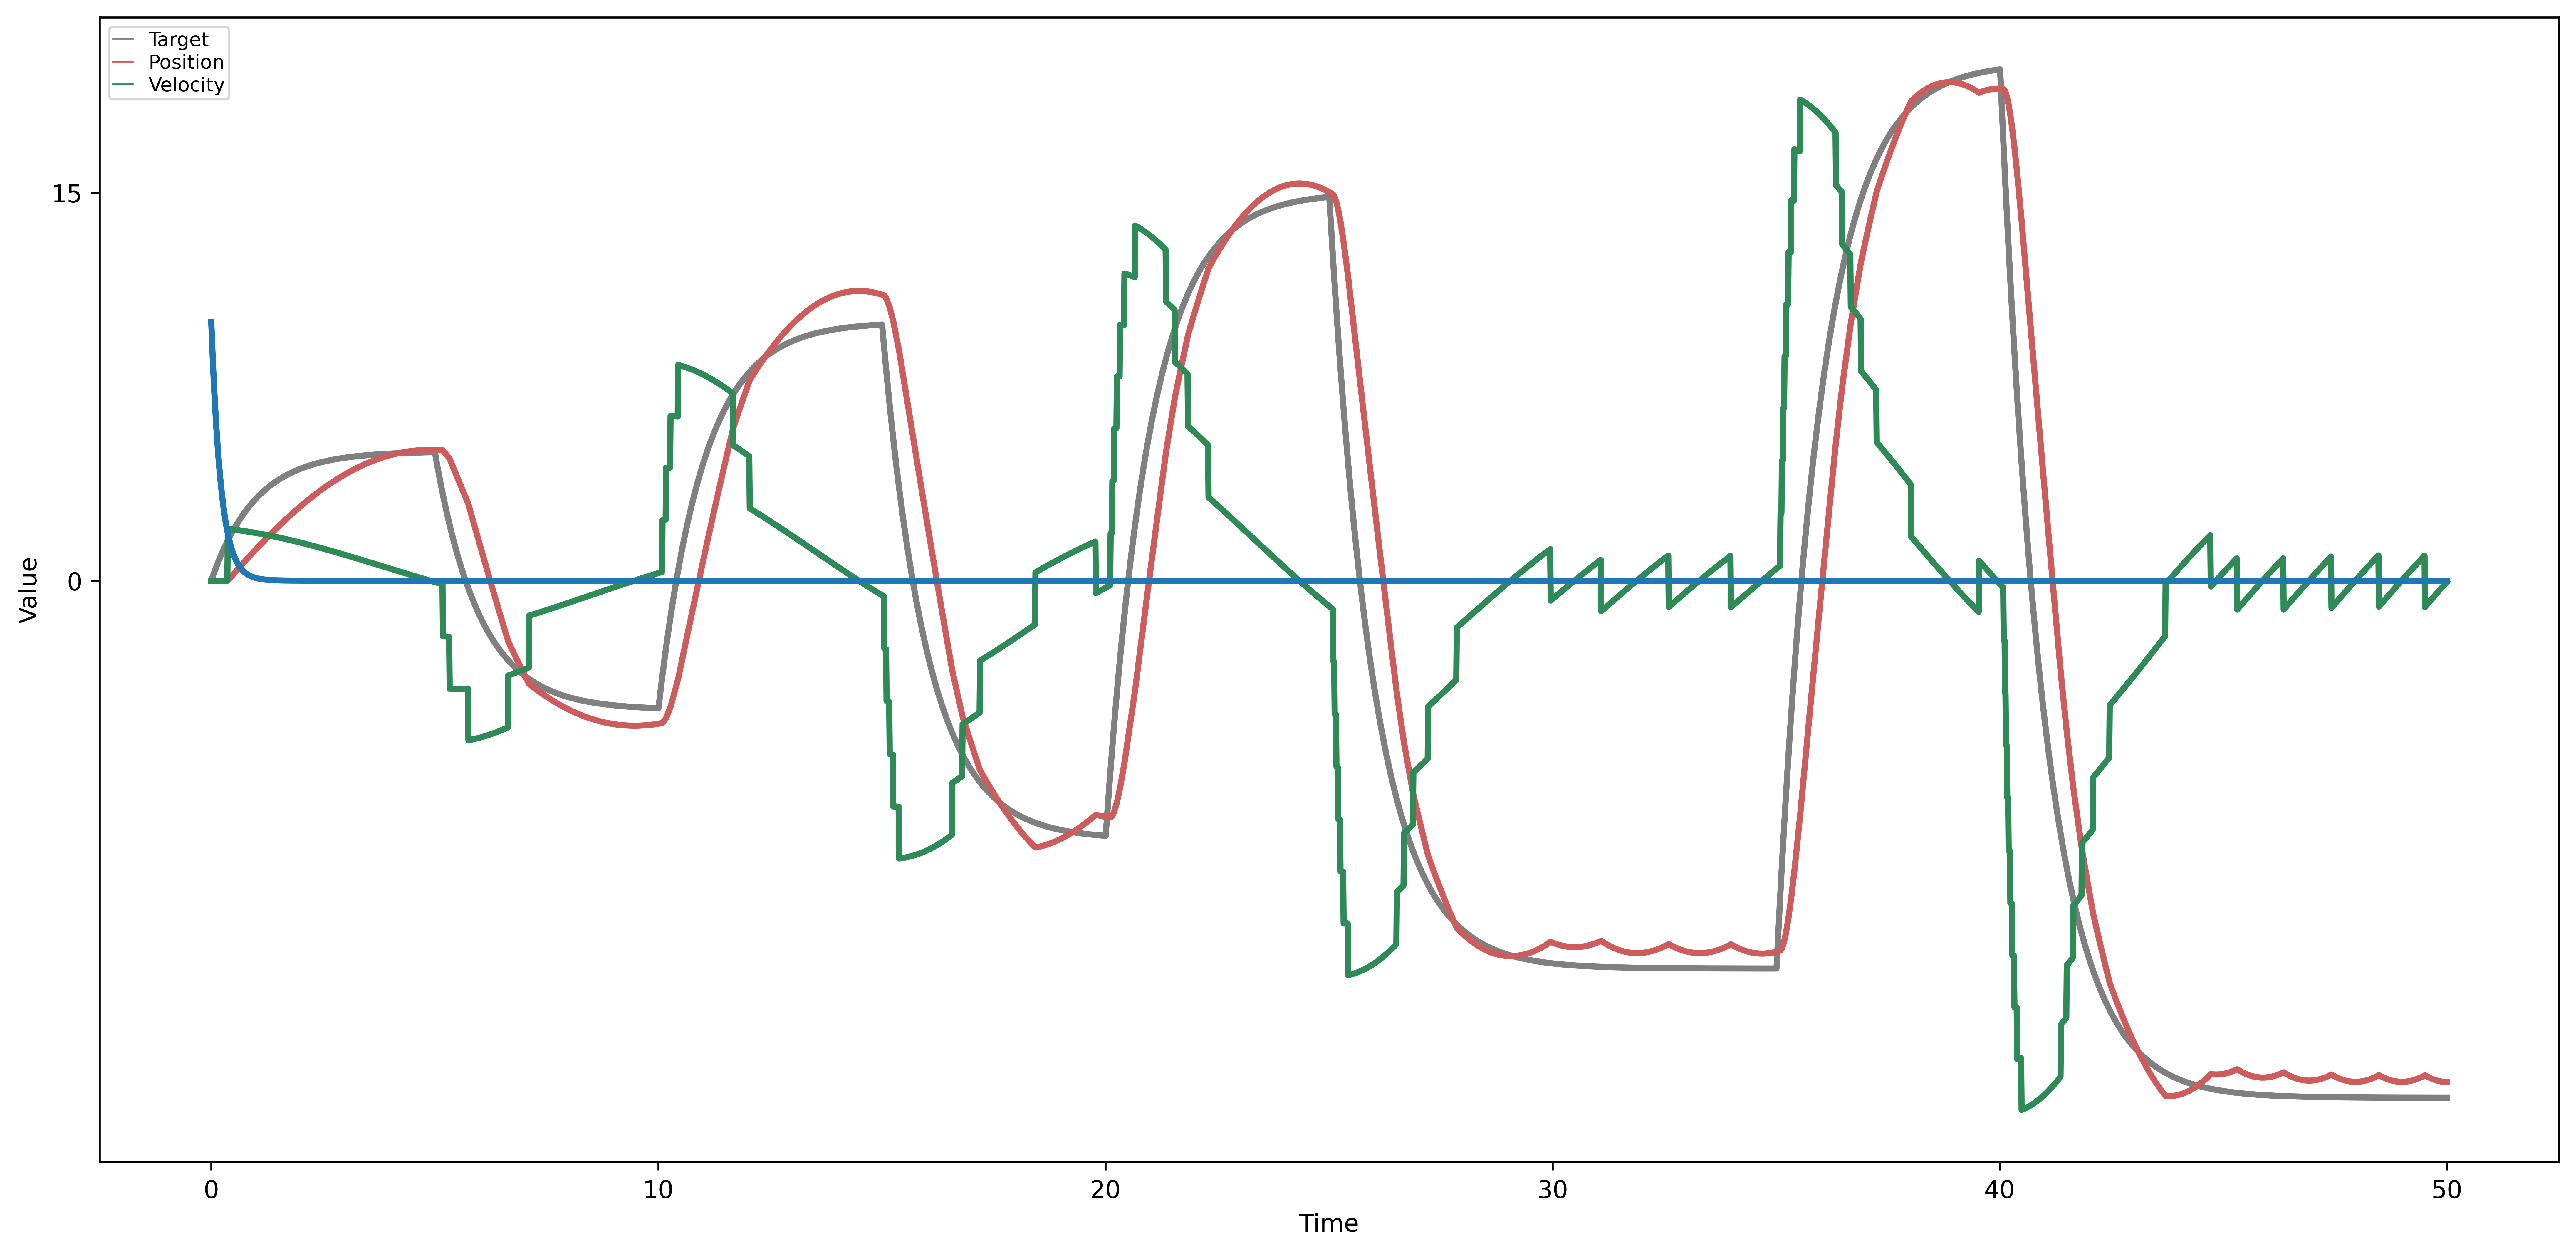

In [62]:
#General figure layout
outer_nested_mosaic = [
    ['A']
]

#Generate figure and axes
fig, axs = plt.subplot_mosaic(
    outer_nested_mosaic, 
    layout='constrained',
    figsize=(14.5, 7),  
    dpi=600
)

lib_plot.plotTimesVSXs(x, z, x_pred, error_spiking, time, ax=axs['A'], timelabels=True, moment=False, hide=False)
plt.plot(time, 10*lam**(time))
for line in axs['A'].lines:
    line.set_linewidth(2.5)
plt.plot()

In [63]:
lam

0.01

In [64]:
time

array([0.000e+00, 1.000e-02, 2.000e-02, ..., 4.997e+01, 4.998e+01,
       4.999e+01])